### Cancellation model
* LightGBM classifier for the probability that a hotel booking is canceled, trained on the synthetic booking stream
* training rows are complete arrival cohorts of the full history before the validation cohort, every booking observed at random dates between booking and departure from the books
* validation cohort are the arrivals of the 120 days before the snapshot, early stopping and the calibrator use it, the training rows never do
* the calibrator is fit with the exposure weights only, so the probabilities match the population of bookings alive on a given day; the class balance weight is for the learner alone
* every landmark row weighted by the days its booking spent on the books, so the rows represent booking days and the probabilities hold at booking time as well as later, times a class balance weight recomputed from the training rows at every training run
* category levels, rate medians and percentile caps are learned on the training rows only and saved with the artifact
* feature set of 49 features and the hyperparameters chosen by the reliability rule of the experiments notebook: lowest validation log loss with the train against validation gap within its limit
* tests on bookings on the books at the snapshot, arrivals of the eight weeks after the snapshot and bookings made after the snapshot
* exports the model artifact with its recipe, the metrics and the learning curve with the feature importance for the server

In [1]:
import os
import sys
import json
import shap
import joblib
import datetime
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss
warnings.filterwarnings("ignore")

In [2]:
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, ROOT_DIR)

from app.models import context
from app.models import features
from app.models import preprocess

In [3]:
# paths and the training recipe, the snapshot is 90 days ago on the stream calendar
PARQUET_PATH = os.path.join(ROOT_DIR, "data", "parquet", "bookings.parquet")
WEATHER_PATH = os.path.join(ROOT_DIR, "data", "parquet", "weather.parquet")
HOLIDAYS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "holidays.parquet")
MODELS_DIR = os.path.join(ROOT_DIR, "data", "models")
snapshot = pd.Timestamp(datetime.date.today() - datetime.timedelta(days=90))
valid_days = 120
near_days = 56
window_years = None
samples_per_booking = 2
cap = None
cap_mode = "clip"
scaling = "none"
class_weight = "balanced"
exposure_weight = True
calibration = "isotonic"
clip = [0.005, 0.99]
rounds = 4000
patience = 150
cost_missed_cancel = 1.0
cost_false_alarm = 2.0
rng = np.random.default_rng(7)
params = {'objective': 'binary', 'metric': ['binary_logloss', 'auc'], 'learning_rate': 0.05, 'num_leaves': 22, 'min_data_in_leaf': 333, 'feature_fraction': 0.4, 'bagging_fraction': 0.7, 'bagging_freq': 1, 'lambda_l2': 100.0, 'cat_smooth': 100.0, 'verbose': -1, 'num_threads': 3, 'seed': 7, 'lambda_l1': 1.0, 'max_depth': -1, 'min_gain_to_split': 0.5, 'extra_trees': False, 'path_smooth': 10.0, 'cat_l2': 10.0, 'min_data_per_group': 100, 'max_bin': 63}
feature_list = ["hotel", "meal", "country", "market_segment", "distribution_channel", "reserved_room_type", "deposit_type", "agent", "company", "customer_type", "lead_time", "nights", "stays_in_week_nights", "previous_cancellations", "previous_bookings_not_canceled", "days_in_waiting_list", "adr", "required_car_parking_spaces", "total_of_special_requests", "arrival_month", "arrival_week", "booking_month", "adr_per_person", "days_since_booking", "days_to_arrival", "survived_share", "arr_temp_max", "arr_precip_mm", "arr_weather_known", "agent_prior_rate", "agent_prior_n", "country_prior_rate", "rel_price", "is_portugal", "prev_cancel_ratio", "has_prior_cancellation", "completed_stays", "no_request", "requests_per_guest", "lead_bucket", "rel_price_lead", "agent_recency_days", "agent_prior_365", "agent_avg_lead_365", "agent_lead_index", "agent_adr_index", "country_prior_365", "country_share_365", "booking_days_to_month_end"]
model_version = "cancellation_v12"

In [4]:
# load the staged bookings whose outcome is known, bookings still open are left out
def load_bookings(path):
    frame = pd.read_parquet(path)
    for col in ["arrival_date", "booking_date", "leave_books_date"]:
        frame[col] = pd.to_datetime(frame[col])
    frame = frame[(frame["adr"] >= 0) & (frame["adr"] < 1000) & (frame["outcome_known"] == True)].copy()
    frame["is_canceled"] = frame["is_canceled"].astype(int)
    return frame.reset_index(drop=True)

In [5]:
# load weather and holiday tables used for the context features
def load_context(weather_path, holidays_path):
    weather = pd.read_parquet(weather_path)
    holidays = pd.read_parquet(holidays_path)
    return weather, holidays

In [6]:
# time based cohorts: training window of arrivals before the validation cohort, validation arrivals before the snapshot and three test sets after it; the on the books set keeps arrivals within 90 days of the snapshot so that every outcome is known today
def split_cohorts(frame, snapshot):
    train_end = snapshot - pd.Timedelta(days=valid_days)
    train_start = train_end - pd.DateOffset(years=window_years) if window_years is not None else frame["arrival_date"].min() - pd.Timedelta(days=1)
    out = {}
    out["train"] = frame[(frame["arrival_date"] > train_start) & (frame["arrival_date"] <= train_end)]
    out["valid"] = frame[(frame["arrival_date"] > train_end) & (frame["arrival_date"] <= snapshot)]
    out["on_books"] = frame[(frame["booking_date"] <= snapshot) & (frame["leave_books_date"] > snapshot) & (frame["arrival_date"] > snapshot) & (frame["arrival_date"] <= snapshot + pd.Timedelta(days=90))]
    out["near"] = frame[(frame["arrival_date"] > snapshot) & (frame["arrival_date"] <= snapshot + pd.Timedelta(days=near_days))]
    out["future"] = frame[frame["booking_date"] > snapshot]
    return out

In [7]:
# expand bookings into as of observations at random dates between booking and departure from the books, with the days on the books as exposure
def landmark(frame, k):
    parts = []
    for i in range(k):
        out = frame.copy()
        span = (out["leave_books_date"].clip(upper=out["arrival_date"]) - out["booking_date"]).dt.days.clip(lower=0)
        offset = np.floor(rng.random(len(out)) * (span.values + 1))
        out["as_of"] = out["booking_date"] + pd.to_timedelta(offset, unit="D")
        out["exposure"] = span.values + 1
        parts.append(out)
    return pd.concat(parts, ignore_index=True)

In [8]:
# observe a frame at one fixed date or at a date column
def observe_at(frame, date):
    out = frame.copy()
    out["as_of"] = date
    return out

In [9]:
# feature matrix of the recipe for an observed frame, preprocessing state applied when given
def build_matrix(frame, levels, state=None):
    x = features.transform(frame, levels)[feature_list]
    if state is not None:
        x = preprocess.apply_preprocessing(x, state)
    return x

In [10]:
# exposure weights: days on the books so the rows represent booking days, the population the calibrator must match
def exposure_weights(frame):
    if not exposure_weight:
        return np.ones(len(frame))
    return frame["exposure"].values / frame["exposure"].values.mean()

In [11]:
# sample weights of the learner: exposure times the class balance option, the balance never enters the calibrator
def sample_weights(frame):
    y = frame["is_canceled"].values
    weight = np.ones(len(frame))
    if exposure_weight:
        weight = frame["exposure"].values / frame["exposure"].values.mean()
    if class_weight == "balanced":
        share = float(y.mean())
        weight = weight * np.where(y == 1, 0.5 / share, 0.5 / (1 - share))
    return weight

In [12]:
# train lightgbm with early stopping on the validation cohort, loss and auc recorded per iteration on both sets
def train_model(x_train, y_train, x_valid, y_valid, w_train, w_valid):
    d_train = lgb.Dataset(x_train, label=y_train, weight=w_train)
    d_valid = lgb.Dataset(x_valid, label=y_valid, weight=w_valid, reference=d_train)
    history = {}
    callbacks = [lgb.early_stopping(patience, first_metric_only=True, verbose=False), lgb.record_evaluation(history)]
    model = lgb.train(params, d_train, num_boost_round=rounds, valid_sets=[d_train, d_valid], valid_names=["train", "validation"], callbacks=callbacks)
    return model, history

In [13]:
# learning curve table, loss and auc per boosting iteration for the train and validation sets
def learning_curve_table(history, best_iteration):
    out = {}
    out["iteration"] = list(range(1, len(history["train"]["binary_logloss"]) + 1))
    out["train_loss"] = [round(float(v), 5) for v in history["train"]["binary_logloss"]]
    out["test_loss"] = [round(float(v), 5) for v in history["validation"]["binary_logloss"]]
    out["train_auc"] = [round(float(v), 5) for v in history["train"]["auc"]]
    out["test_auc"] = [round(float(v), 5) for v in history["validation"]["auc"]]
    out["best_iteration"] = int(best_iteration)
    return out

In [14]:
# learning curves, train against validation per boosting iteration for the loss and for auc
def plot_learning_curves(curve):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(curve["iteration"], curve["train_loss"], color="blue", label="train")
    axes[0].plot(curve["iteration"], curve["test_loss"], color="red", label="validation")
    axes[0].axvline(curve["best_iteration"], color="gray", linestyle="--", label="best iteration")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("binary log loss")
    axes[0].legend()
    axes[1].plot(curve["iteration"], curve["train_auc"], color="blue", label="train")
    axes[1].plot(curve["iteration"], curve["test_auc"], color="red", label="validation")
    axes[1].axvline(curve["best_iteration"], color="gray", linestyle="--", label="best iteration")
    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("roc auc")
    axes[1].legend()
    fig.suptitle("Learning curves")
    plt.tight_layout()
    plt.show()

In [15]:
# calibrated probability for an observed frame, the seasonal calibrator reads the arrival month
def predict(model, calibrator, frame, levels, state):
    raw = model.predict(build_matrix(frame, levels, state), num_iteration=model.best_iteration)
    return preprocess.calibrate(calibrator, raw, frame["arrival_date"].dt.month.values)

In [16]:
# expected calibration error on quantile bins
def ece(p, y, bins=15):
    edges = np.quantile(p, np.linspace(0, 1, bins + 1))
    idx = np.clip(np.searchsorted(edges, p, side="right") - 1, 0, bins - 1)
    total = 0.0
    for b in range(bins):
        mask = idx == b
        if mask.any():
            total += mask.mean() * abs(p[mask].mean() - y[mask].mean())
    return float(total)

In [17]:
# classification and probability quality metrics
def evaluate(p, y):
    out = {}
    out["rows"] = int(len(y))
    out["base_rate"] = round(float(np.mean(y)), 4)
    out["roc_auc"] = round(float(roc_auc_score(y, p)), 4)
    out["pr_auc"] = round(float(average_precision_score(y, p)), 4)
    out["brier"] = round(float(brier_score_loss(y, p)), 4)
    out["brier_base"] = round(float(brier_score_loss(y, np.full(len(y), np.mean(y)))), 4)
    out["log_loss"] = round(float(log_loss(y, np.clip(p, 1e-6, 1 - 1e-6))), 4)
    out["ece"] = round(ece(p, y), 4)
    out["share_above_0.99"] = round(float((p > 0.99).mean()), 4)
    return out

In [18]:
# threshold that minimises expected cost of missed cancellations and false alarms
def choose_threshold(p, y, cost_fn, cost_fp):
    grid = np.arange(0.05, 0.96, 0.01)
    costs = []
    for t in grid:
        pred = p >= t
        fn = np.sum((pred == 0) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        costs.append(fn * cost_fn + fp * cost_fp)
    best = int(np.argmin(costs))
    return float(grid[best]), float(costs[best])

In [19]:
# reliability curve of calibrated probabilities
def plot_reliability(p, y, title):
    frac, mean_p = calibration_curve(y, p, n_bins=15, strategy="quantile")
    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="perfect")
    plt.plot(mean_p, frac, marker="o", color="blue", label="model")
    plt.xlabel("predicted probability")
    plt.ylabel("observed cancellation rate")
    plt.title(title)
    plt.legend()
    plt.show()

In [20]:
# reliability table on quantile bins, predicted against observed rate with the bin size
def reliability_table(p, y, bins=10):
    edges = np.quantile(p, np.linspace(0, 1, bins + 1))
    idx = np.clip(np.searchsorted(edges, p, side="right") - 1, 0, bins - 1)
    rows = []
    for b in range(bins):
        mask = idx == b
        if mask.any():
            rows.append({"bin": b + 1, "rows": int(mask.sum()), "predicted": round(float(p[mask].mean()), 4), "observed": round(float(y[mask].mean()), 4)})
    return rows

In [21]:
# gain based feature importance, all features as a table and the top ones as a bar chart
def plot_importance(model, top=20):
    imp = pd.Series(model.feature_importance("gain"), index=model.feature_name()).sort_values(ascending=False)
    head = imp.head(top)
    plt.figure(figsize=(7, 6))
    plt.barh(head.index[::-1], head.values[::-1], color="steelblue")
    plt.xlabel("gain")
    plt.title("Feature importance")
    plt.show()
    return imp

In [22]:
# shap summary on a sample of test rows
def plot_shap(model, x, n=2000):
    sample = x.sample(min(n, len(x)), random_state=7)
    explainer = shap.TreeExplainer(model)
    explanation = explainer(sample)
    shap.summary_plot(explanation, max_display=15, show=False)
    plt.title("SHAP summary")
    plt.show()

In [23]:
# save the model artifact with its recipe and preprocessing state, the metrics file and the learning curve file with the feature importance
def export(model, calibrator, levels, state, metrics, threshold, curve, importance):
    os.makedirs(MODELS_DIR, exist_ok=True)
    recipe = {"window_years": window_years, "features": feature_list, "cap": cap, "cap_mode": cap_mode, "scaling": scaling, "samples_per_booking": samples_per_booking, "calibration": calibration, "clip": clip, "class_weight": class_weight, "exposure_weight": exposure_weight, "valid_days": valid_days, "holdout_days": 60, "params": params, "rounds": rounds, "patience": patience}
    artifact = {"model": model, "calibrator": calibrator, "levels": levels, "features": feature_list, "threshold": threshold, "context": True, "params": params, "recipe": recipe, "samples_per_booking": samples_per_booking, "best_iteration": int(model.best_iteration), "clip": tuple(clip), "family": "lightgbm", "version": model_version, "snapshot": str(snapshot.date()), "trained_at": datetime.datetime.now(datetime.timezone.utc).isoformat()}
    artifact.update(state)
    joblib.dump(artifact, os.path.join(MODELS_DIR, model_version + ".joblib"))
    with open(os.path.join(MODELS_DIR, model_version + "_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)
    share = importance / importance.sum()
    rows = [{"feature": k, "gain": round(float(v), 1), "share": round(float(share[k]), 4)} for k, v in importance.items()]
    curves = {"version": model_version, "learning_curve": curve, "importance": rows, "trained_at": artifact["trained_at"]}
    with open(os.path.join(MODELS_DIR, model_version + "_curves.json"), "w") as f:
        json.dump(curves, f)
    print("saved " + os.path.join(MODELS_DIR, model_version + ".joblib"))

In [24]:
bookings = load_bookings(PARQUET_PATH)
weather, holidays = load_context(WEATHER_PATH, HOLIDAYS_PATH)
cohorts = split_cohorts(bookings, snapshot)
train = context.add_context(landmark(cohorts["train"], samples_per_booking), weather, holidays)
valid = context.add_context(landmark(cohorts["valid"], samples_per_booking), weather, holidays)
tests = {}
tests["on_books"] = context.add_context(observe_at(cohorts["on_books"], snapshot), weather, holidays)
tests["near"] = context.add_context(observe_at(cohorts["near"], cohorts["near"]["booking_date"]), weather, holidays)
tests["future"] = context.add_context(observe_at(cohorts["future"], cohorts["future"]["booking_date"]), weather, holidays)
print("snapshot " + str(snapshot.date()) + ", training arrivals from " + str(cohorts["train"]["arrival_date"].min().date()) + " to " + str(cohorts["train"]["arrival_date"].max().date()))
print("train rows " + str(len(train)) + " from " + str(len(cohorts["train"])) + " bookings, valid rows " + str(len(valid)) + ", " + ", ".join(k + " rows " + str(len(v)) for k, v in tests.items()))
print("cancel rate train " + str(round(train["is_canceled"].mean(), 4)) + ", valid " + str(round(valid["is_canceled"].mean(), 4)) + ", " + ", ".join(k + " " + str(round(v["is_canceled"].mean(), 4)) for k, v in tests.items()))

snapshot 2026-06-29, training arrivals from 2014-01-06 to 2026-03-01
train rows 1251120 from 625560 bookings, valid rows 44138, on_books rows 8171, near rows 9115, future rows 5073
cancel rate train 0.2617, valid 0.2752, on_books 0.1231, near 0.2832, future 0.3603


In [25]:
levels = features.fit_levels(train)
num_cols = [c for c in feature_list if c not in features.categorical_columns]
x_train = build_matrix(train, levels)
state = preprocess.fit_preprocessing(x_train, num_cols, {"cap": cap, "cap_mode": cap_mode, "scaling": scaling})
x_train = preprocess.apply_preprocessing(x_train, state)
x_valid = build_matrix(valid, levels, state)
y_train = train["is_canceled"].values
y_valid = valid["is_canceled"].values
w_train = sample_weights(train)
w_valid = sample_weights(valid)
print("features " + str(x_train.shape[1]) + ", capped columns " + str(len(state["caps"])) + ", scaler " + str(type(state["scaler"]).__name__ if state["scaler"] is not None else "none"))

features 49, capped columns 0, scaler none


best iteration 1102, iterations run 1252
train log loss at best iteration 0.33615, validation 0.34233
train auc at best iteration 0.92257, validation 0.91129


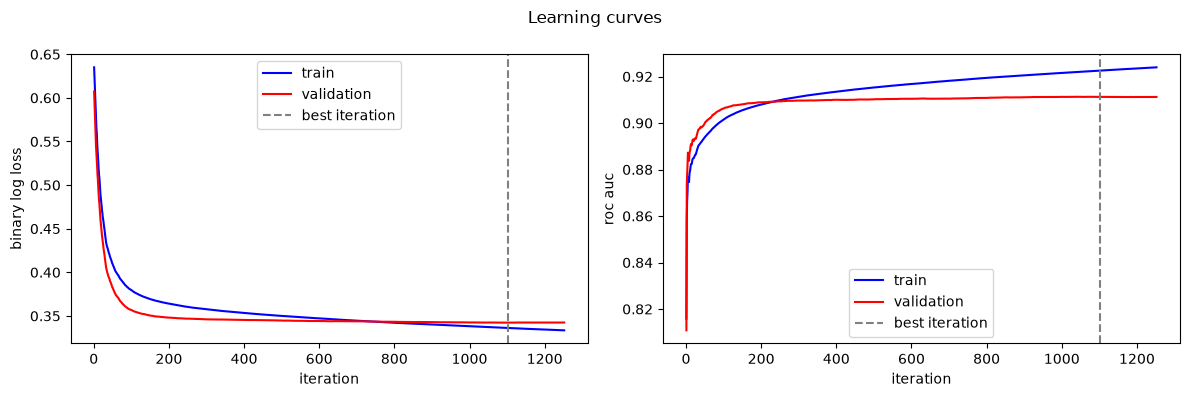

In [26]:
model, history = train_model(x_train, y_train, x_valid, y_valid, w_train, w_valid)
raw_valid = model.predict(x_valid, num_iteration=model.best_iteration)
calibrator = preprocess.fit_calibrator(raw_valid, y_valid, calibration, clip, exposure_weights(valid), valid["arrival_date"].dt.month.values)
curve = learning_curve_table(history, model.best_iteration)
print("best iteration " + str(model.best_iteration) + ", iterations run " + str(len(curve["iteration"])))
print("train log loss at best iteration " + str(curve["train_loss"][model.best_iteration - 1]) + ", validation " + str(curve["test_loss"][model.best_iteration - 1]))
print("train auc at best iteration " + str(curve["train_auc"][model.best_iteration - 1]) + ", validation " + str(curve["test_auc"][model.best_iteration - 1]))
plot_learning_curves(curve)

In [27]:
metrics = {}
metrics["validation"] = evaluate(preprocess.calibrate(calibrator, raw_valid, valid["arrival_date"].dt.month.values), y_valid)
predictions = {}
for name, frame in tests.items():
    predictions[name] = predict(model, calibrator, frame, levels, state)
    metrics[name] = evaluate(predictions[name], frame["is_canceled"].values)
for name, m in metrics.items():
    print(name + ": " + json.dumps(m))

validation: {"rows": 44138, "base_rate": 0.2752, "roc_auc": 0.9181, "pr_auc": 0.8053, "brier": 0.114, "brier_base": 0.1995, "log_loss": 0.3573, "ece": 0.0857, "share_above_0.99": 0.0}
on_books: {"rows": 8171, "base_rate": 0.1231, "roc_auc": 0.9144, "pr_auc": 0.6618, "brier": 0.065, "brier_base": 0.108, "log_loss": 0.2159, "ece": 0.0068, "share_above_0.99": 0.0}
near: {"rows": 9115, "base_rate": 0.2832, "roc_auc": 0.8938, "pr_auc": 0.7772, "brier": 0.1148, "brier_base": 0.203, "log_loss": 0.3586, "ece": 0.0181, "share_above_0.99": 0.0}
future: {"rows": 5073, "base_rate": 0.3603, "roc_auc": 0.8888, "pr_auc": 0.8186, "brier": 0.1449, "brier_base": 0.2305, "log_loss": 0.4433, "ece": 0.104, "share_above_0.99": 0.0}


threshold 0.6300000000000001, expected cost 785.0, cost with no model 1006.0


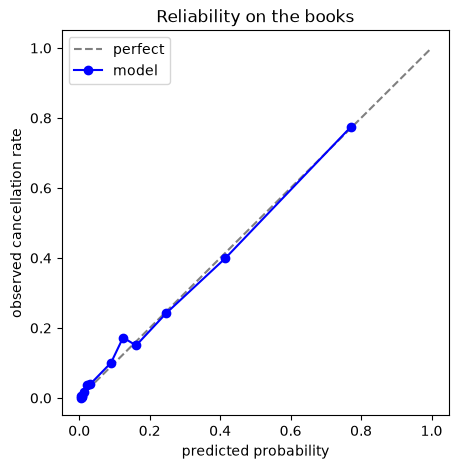

In [28]:
p_books = predictions["on_books"]
y_books = tests["on_books"]["is_canceled"].values
threshold, cost = choose_threshold(p_books, y_books, cost_missed_cancel, cost_false_alarm)
metrics["threshold"] = threshold
metrics["expected_cost_at_threshold"] = cost
metrics["expected_cost_predict_none"] = float(np.sum(y_books) * cost_missed_cancel)
metrics["reliability_on_books"] = reliability_table(p_books, y_books)
metrics["reliability_label"] = "offline, on the books at the snapshot"
print("threshold " + str(threshold) + ", expected cost " + str(cost) + ", cost with no model " + str(metrics["expected_cost_predict_none"]))
plot_reliability(p_books, y_books, "Reliability on the books")

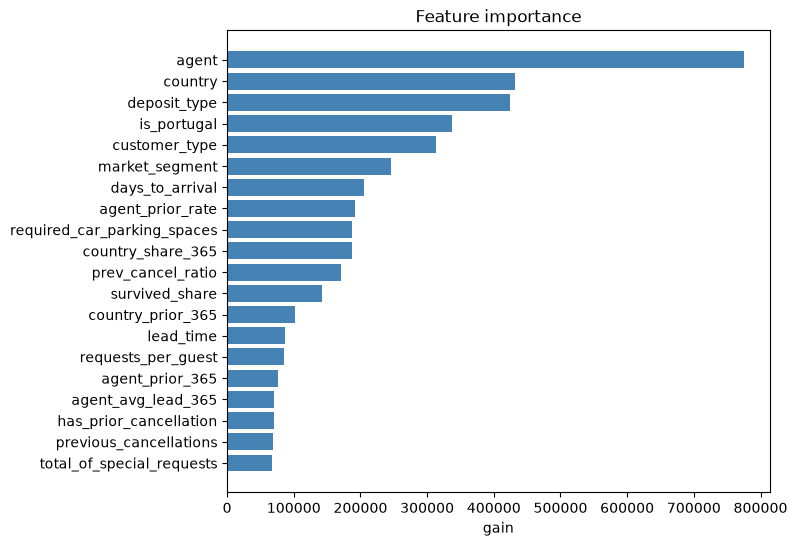

agent                          774865.0
country                        431914.0
deposit_type                   424740.0
is_portugal                    337869.0
customer_type                  312639.0
market_segment                 245861.0
days_to_arrival                205268.0
agent_prior_rate               191260.0
required_car_parking_spaces    188071.0
country_share_365              188037.0
prev_cancel_ratio              171452.0
survived_share                 141751.0
country_prior_365              101445.0
lead_time                       86600.0
requests_per_guest              84678.0
agent_prior_365                 76595.0
agent_avg_lead_365              70591.0
has_prior_cancellation          69747.0
previous_cancellations          68964.0
total_of_special_requests       67213.0


In [29]:
importance = plot_importance(model)
print(importance.head(20).round(0).to_string())

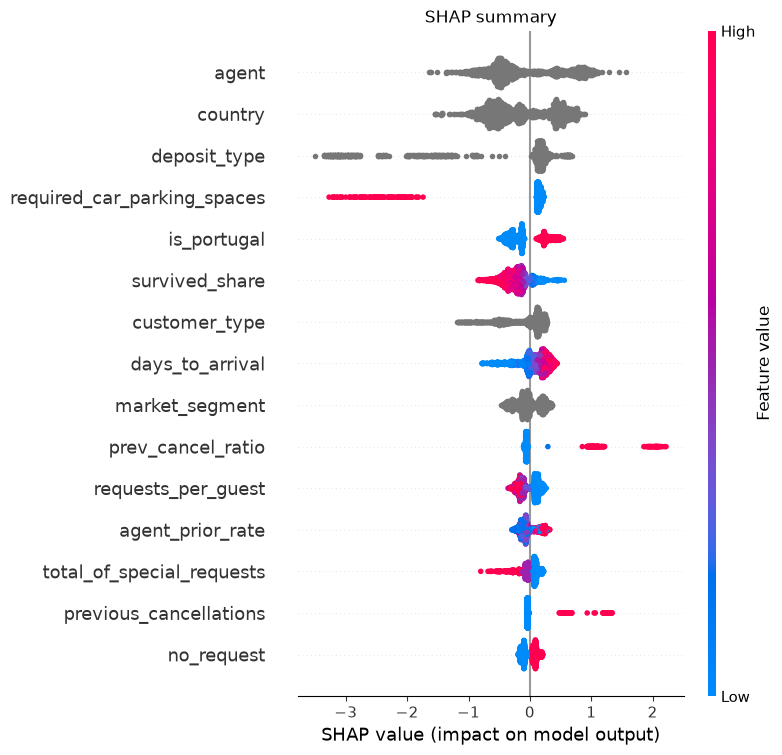

In [30]:
plot_shap(model, build_matrix(tests["on_books"], levels, state))

In [31]:
metrics["version"] = model_version
metrics["snapshot"] = str(snapshot.date())
metrics["best_iteration"] = int(model.best_iteration)
metrics["train_rows"] = int(len(train))
metrics["train_bookings"] = int(len(cohorts["train"]))
metrics["window_years"] = window_years
metrics["feature_list"] = feature_list
export(model, calibrator, levels, state, metrics, threshold, curve, importance)

saved /srv/data/models/cancellation_v12.joblib
